All your life you've never seen, woman <br>
Taken by the wind <br>
Would you stay if she promised you heaven? <br>
Will you ever win? <br>

# Imports and setups

In [1]:
import tensorflow as tf
from tensorflow.python.platform import self_check

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)

GPUs: []


In [86]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("D:/Facial Recognition/")
import cv2 
import uuid
tf.config.list_physical_devices('GPU')

[]

# Creating folder structure

In [3]:
POSITIVES = os.path.join("data", "positive")
NEGATIVES = os.path.join("data", "negative")
ANCHORS = os.path.join("data", "anchors")
dirs = [POSITIVES, NEGATIVES, ANCHORS]
for dir in dirs :
    os.makedirs(dir, exist_ok = True)
print(os.path.abspath("data"))

D:\Facial Recognition\data


In [4]:
for directory in os.listdir("lfw"):
    for filename in os.listdir(os.path.join("lfw", directory)):
        EX_PATH = os.path.join("lfw", directory, filename)
        NEW_PATH = os.path.join(NEGATIVES, filename)
        os.replace(EX_PATH, NEW_PATH)

In [5]:
for filename in os.listdir(NEGATIVES):
    print(os.path.join(NEGATIVES, filename))

data\negative\Aaron_Eckhart_0001.jpg
data\negative\Aaron_Guiel_0001.jpg
data\negative\Aaron_Patterson_0001.jpg
data\negative\Aaron_Peirsol_0001.jpg
data\negative\Aaron_Peirsol_0002.jpg
data\negative\Aaron_Peirsol_0003.jpg
data\negative\Aaron_Peirsol_0004.jpg
data\negative\Aaron_Pena_0001.jpg
data\negative\Aaron_Sorkin_0001.jpg
data\negative\Aaron_Sorkin_0002.jpg
data\negative\Aaron_Tippin_0001.jpg
data\negative\Abbas_Kiarostami_0001.jpg
data\negative\Abba_Eban_0001.jpg
data\negative\Abdel_Aziz_Al-Hakim_0001.jpg
data\negative\Abdel_Madi_Shabneh_0001.jpg
data\negative\Abdel_Nasser_Assidi_0001.jpg
data\negative\Abdel_Nasser_Assidi_0002.jpg
data\negative\Abdoulaye_Wade_0001.jpg
data\negative\Abdoulaye_Wade_0002.jpg
data\negative\Abdoulaye_Wade_0003.jpg
data\negative\Abdoulaye_Wade_0004.jpg
data\negative\Abdulaziz_Kamilov_0001.jpg
data\negative\Abdullah_0001.jpg
data\negative\Abdullah_0002.jpg
data\negative\Abdullah_0003.jpg
data\negative\Abdullah_0004.jpg
data\negative\Abdullah_Ahmad_Badaw

# Accessing the WebCam using OpenCV

In [6]:
# verifying if the camera be worken
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("opened:", cap.isOpened())
ret, frame = cap.read()
print("ret:", ret)

opened: True
ret: True


In [7]:
cap = cv2.VideoCapture(0)
while cap.isOpened() :
    ret, frame = cap.read()
    if not ret :
        break

    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    cv2.imshow("Image Collection", frame)
    # collecting the anchors
    if (cv2.waitKey(1) & 0xFF == ord('a')) :
        imgname = os.path.join(ANCHORS, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the positives
    if (cv2.waitKey(1) & 0xFF == ord('p')) :
        imgname = os.path.join(POSITIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the negatives
    if (cv2.waitKey(1) & 0xFF == ord('n')) :
        imgname = os.path.join(NEGATIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    if (cv2.waitKey(1) & 0xFF == ord('q')) :
        break
cap.release()
cv2.destroyAllWindows()

In [8]:
# # in case of ip webcam
# import os
# import cv2
# import numpy as np
# from IPython.display import display
# from PIL import Image

# PHONE_STREAM_URL = os.getenv("PHONE_STREAM_URL", "http://192.168.0.108:8080/video")
# print("Using phone stream URL:", PHONE_STREAM_URL)

# cap = cv2.VideoCapture(PHONE_STREAM_URL)

# if not cap.isOpened():
#     raise RuntimeError(
#         "Could not open the phone stream.\n"
#         "Check that IP Webcam is running on your phone and that the URL is correct."
#     )

# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

# print("Phone stream opened successfully")
# print("Press q in the notebook cell output to stop")

# for _ in range(30):
#     ret, frame = cap.read()
#     if not ret:
#         print("Failed to read a frame from the phone stream")
#         break

#     frame = cv2.resize(frame, (320, 240))
#     frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
#     frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     img = Image.fromarray(frame_rgb)
#     display(img)

# cap.release()

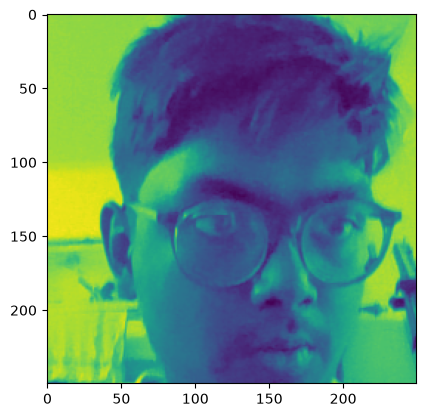

In [9]:
plt.imshow(frame[:, :, 1])

In [89]:
anchor = tf.data.Dataset.list_files(ANCHORS + "\\*.jpg").take(300)
positive = tf.data.Dataset.list_files(POSITIVES + "\\*.jpg").take(300)
negative = tf.data.Dataset.list_files(NEGATIVES + "\\*.jpg").take(300)

In [11]:
ANCHORS

'data\\anchors'

In [12]:
def preprocess (file_path) :
    """
    Params : file_path
    Preprocesses the images for the neural network by resizing to (100, 100) and scaling b/w [0, 1] by dividing by 255.0
    """
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)
    img = tf.image.resize(img, (100, 100))
    # scaling b/w 0 and 1 to make sure numbers dont go all over the place
    img /= 255
    return img


Text(0.5, 1.0, 'BUGGU (scaled down to [100 : 100])')

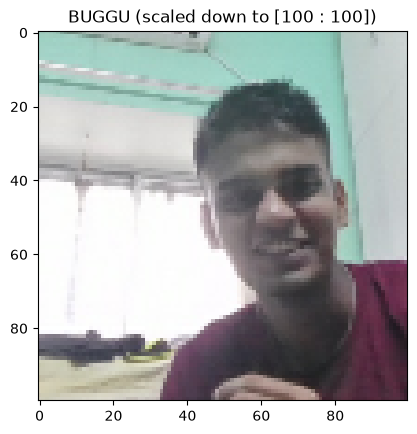

In [13]:
plt.imshow(preprocess("data//anchors//8638ff34-8f22-11f1-8029-00155dcd2f0b.jpg"))
plt.title("BUGGU (scaled down to [100 : 100])")

In [14]:
preprocess("data//anchors//51a6b4a8-8e5e-11f1-ad31-be86ceb3559f.jpg").numpy()[:, :, 1].min()

np.float32(0.0700392)

# Creating Labelled Dataset

In [51]:
positive_dataset = tf.data.Dataset.zip((
    anchor,
    positive,
    tf.data.Dataset.from_tensor_slices(tf.ones([len(anchor)], dtype = tf.float32))
))
negative_dataset = tf.data.Dataset.zip((
    anchor,
    negative,
    tf.data.Dataset.from_tensor_slices(tf.zeros([len(anchor)], dtype = tf.float32))
))
data = positive_dataset.concatenate(negative_dataset)

In [64]:
print(tf.data.experimental.cardinality(positive_dataset).numpy())
print(tf.data.experimental.cardinality(negative_dataset).numpy())
print(tf.data.experimental.cardinality(data).numpy())

75
85
160


In [66]:
for element in data : print(element)

(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\8638ff34-8f22-11f1-8029-00155dcd2f0b.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\8bbceca9-8f22-11f1-978f-00155dcd2f0b.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\5ecce161-9218-11f1-815d-00155df46725.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\5b373df5-9218-11f1-81b1-00155df46725.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\446aa963-8e9a-11f1-85d1-be86ceb3559f.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\5d5cd7bb-9218-11f1-a3ad-00155df46725.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\61e45f2b-9218-11f1-97b0-00155df46725.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\48c08c6e-8e5e-11f1-a5eb-be86ceb3559f.jpg'>, <tf.Tensor: shape=(),

# Build Test and Train partition

In [17]:
samples = data.as_numpy_iterator()

In [18]:
example = samples.next()
example

(b'data\\anchors\\4bb83300-8e9a-11f1-95f1-be86ceb3559f.jpg',
 b'data\\positive\\5d55c60e-9218-11f1-a09a-00155df46725.jpg',
 np.float32(1.0))

In [25]:
for idx in range (0, len(example)) : print(type(example[idx]))

<class 'bytes'>
<class 'bytes'>
<class 'numpy.float32'>


In [29]:
def preprocess_positive (input_img, validation_img, label) :
    """
    takes an input image and a validation image and process them with process(img)
    """
    return(preprocess(input_img), preprocess(validation_img), label)

Text(0.5, 1.0, 'Boro botla')

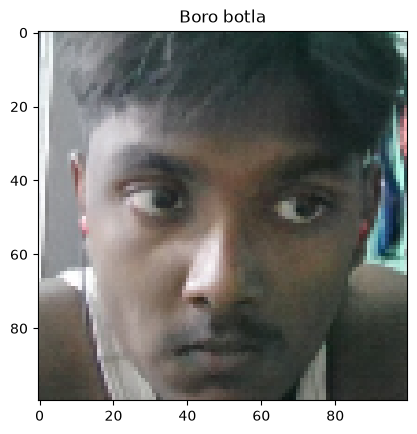

In [67]:
plt.imshow(preprocess_positive(*example)[0])
plt.title("Boro botla")

In [68]:
data = data.map(preprocess_positive)
data = data.cache()
data = data.shuffle(buffer_size = 1024) 

In [69]:
sample = data.as_numpy_iterator()

In [73]:
print(sample.next())

(array([[[0.31691176, 0.35220587, 0.3875    ],
        [0.29264706, 0.33186275, 0.36715686],
        [0.29460785, 0.3367647 , 0.3632353 ],
        ...,
        [0.7058824 , 0.8745098 , 0.8382353 ],
        [0.6990196 , 0.87647057, 0.83431375],
        [0.70098037, 0.8813726 , 0.8382353 ]],

       [[0.33186275, 0.36617646, 0.4034314 ],
        [0.30122548, 0.3367647 , 0.3737745 ],
        [0.3107843 , 0.35      , 0.3855392 ],
        ...,
        [0.7004902 , 0.86985296, 0.8333333 ],
        [0.70661765, 0.88480395, 0.842402  ],
        [0.69803923, 0.88039213, 0.8362745 ]],

       [[0.33406863, 0.37132353, 0.41151962],
        [0.34313726, 0.38088235, 0.42083332],
        [0.34289217, 0.38210785, 0.42058823],
        ...,
        [0.6982843 , 0.87647057, 0.8370098 ],
        [0.7129902 , 0.8933824 , 0.8502451 ],
        [0.69509804, 0.8833333 , 0.8362745 ]],

       ...,

       [[0.90612745, 0.88259804, 0.8982843 ],
        [0.7713235 , 0.7477941 , 0.76348037],
        [0.67156863, 

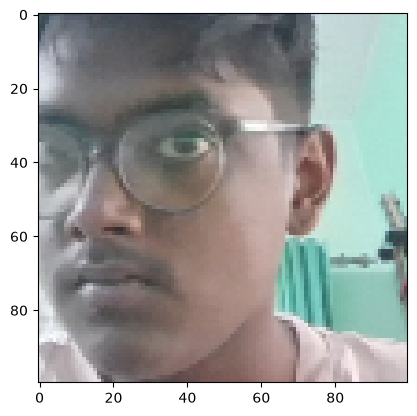

In [74]:
plt.imshow(sample.next()[0])

In [76]:
sample.next()[2]

np.float32(1.0)

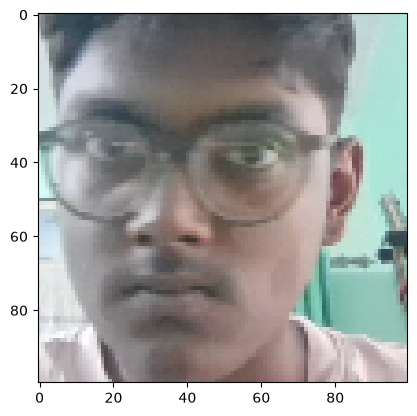

In [75]:
plt.imshow(sample.next()[1])

# Train-Test Split

In [82]:
train_data = data.take(round(len(data) * 0.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [85]:
test_data = data.skip(round(len(data) * 0.7))
test_data = data.take(round(len(data) * 0.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

# Creating the model

In [110]:
from keras import Sequential

model = Sequential([
    Input((100, 100, 3), name = "input_layer"),
    Conv2D(64, (10, 10), activation = "relu", name = "conv_1"),
    MaxPooling2D(64, (2, 2), name = "max_pool_1", padding = "same"),
    Conv2D(128, (7, 7), activation = "relu", name = "conv_2"),
    MaxPooling2D(64, (2, 2), name = "max_pool_2", padding = "same"),
    Conv2D(128, (4, 4), activation = "relu", name = "conv_3"),
    MaxPooling2D(64, (2, 2), name = "max_pool_3", padding = "same"),
    Conv2D(256, (4, 4), activation = "relu", name = "conv_4"),
    Flatten(),
    Dense(4096, activation="sigmoid")
], name = "embedding_model")

model.compile()
model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 17, 17, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling2D)       │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

# Building the distance layer

In [ ]:
# Siamese Distance Class

class L1_distance (Layer) :
    def __init__ (self, **kwargs) :
        super().__init__()

    def call (self, input_embedding, validation_embedding) :
        return tf.math.abs(input_embedding - validation_embedding)

In [113]:
layer1 = L1_distance()